# Single-pulsar joint timing + noise sampling

Demonstrates the JUG-sourced timing-model sampler in `ATLAS.samplers.timing_gibbs`
as an **additive block in ATLAS's block-Gibbs sampler**: the timing model is sampled
jointly with ATLAS's own noise, reusing ATLAS's noise machinery (free-spectrum PSD via
`get_phi_diag`, coefficients analytically marginalised via `get_sigma_from_phiinv`, and
`WhiteCov`) — unchanged.  Timing and red/white noise are sampled together because
low-frequency timing parameters and red noise are covariant; sampling them jointly gives
correct (widened) uncertainties.

**Configure → run → inspect** injection–recovery on **J1600-3053** (DD binary): simulate
noiseless residuals at a truth par, inject known red + white noise, recover, and overlay
the injected truth.

**Validated** (see `VALIDATION.md`): single-pulsar timing + free-spectrum red + white,
unbiased recovery, no systematic displacement over a seed ensemble.  **Not** included:
DM noise, multi-pulsar / GWB, fit-flag automation.

> **Data dependency.** The simulated TOAs are generated from a real NANOGrav 15yr cadence
> template (`make_fake_toas_fromtim`). Point `GBT_TEMPLATE` below at that `.tim` (it ships
> with the JUG pulsar data).

## 1. Configure

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)

REF = os.path.abspath("../reference/bench_scratch")
PAR = f"{REF}/J1600-3053_truth.par"
INJ_JSON = f"{REF}/jug_inj_recovery_J1600-3053.json"
GBT_TEMPLATE = "/home/mattm/soft/JUG/data/pulsars/NG_data/NG_15yr_partim/J1600-3053gbt_PINT_20220302.nb.tim"
SIM_TIM = os.path.abspath("./j1600_sim_noiseless.tim")

INJECT = dict(efac=1.10, log10A_red=-13.0, gamma_red=3.0)   # red + white (no DM)
INJECT_SEED = 20260627
NF_RED = 30
NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS = 300, 500, 2   # demo-length; bump for production
print("jax devices:", jax.devices())

jax devices: [CudaDevice(id=0)]


## 2. Simulate the data
Noiseless residuals at the truth par on the real cadence (PINT), with red + white
injected at `INJECT`/`INJECT_SEED`. Deterministic.

In [2]:
if not os.path.exists(SIM_TIM):
    from pint.models import get_model
    from pint.simulation import make_fake_toas_fromtim, zero_residuals
    m = get_model(PAR)
    t = make_fake_toas_fromtim(GBT_TEMPLATE, model=m, add_noise=False); zero_residuals(t, m)
    t.write_TOA_file(SIM_TIM, format="tempo2"); print(f"generated {SIM_TIM}")
else:
    print(f"reusing {SIM_TIM}")

2026-07-02 20:59:13.983 | DEBUG    | pint.toa:get_TOAs:195 - Using EPHEM = DE440 from the given model


2026-07-02 20:59:13.983 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2019 from the given model


2026-07-02 20:59:13.983 | DEBUG    | pint.toa:get_TOAs:232 - Using PLANET_SHAPIRO = True from the given model


2026-07-02 20:59:16.166 | DEBUG    | pint.toa:apply_clock_corrections:2248 - Applying clock corrections (include_bipm = True)


2026-07-02 20:59:16.550 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)


...

2026-07-02 20:59:37.841 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.


2026-07-02 20:59:37.885 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.


2026-07-02 20:59:37.886 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.


2026-07-02 20:59:37.890 | DEBUG    | pint.models.astrometry:ssb_to_psb_xyz_ECL:983 - ECL not specified; using IERS2010.


generated /home/mattm/soft/ATLAS/notebooks/j1600_sim_noiseless.tim


## 3. Run the sampler
`run_joint_timing_noise`: set up the JUG forward model, route the timing params, build the
frozen timing-only metric, then run 2-block NUTS-within-Gibbs — timing block, and a
noise block (free-spectrum amplitudes + white) using ATLAS's marginalised likelihood.

In [3]:
from ATLAS.samplers.timing_gibbs import JointConfig, run_joint_timing_noise

# --- timing-parameter handling: pick how the timing model is sampled via `timing_mode` ---
# 'sample_all' (default): sample every fitted timing parameter nonlinearly.
# 'fit_flags'            : sample the par's fit-flagged params (identical to sample_all,
#                          since JUG fits exactly the flagged params).
# 'marginalise_linear'   : sample only the nonlinear binary params (M2/SINI/ECC) and
#                          analytically marginalise the linear ones (F0/F1/DM/FD/JUMP/...).
#                          Faster and better-conditioned.
# 'specified'            : sample the params you list; marginalise the rest.
#
# cfg = JointConfig(par=PAR, tim=SIM_TIM, nf_red=NF_RED, inject=INJECT, inject_seed=INJECT_SEED,
#                   timing_mode='sample_all')
# cfg = JointConfig(par=PAR, tim=SIM_TIM, nf_red=NF_RED, inject=INJECT, inject_seed=INJECT_SEED,
#                   timing_mode='marginalise_linear')
# cfg = JointConfig(par=PAR, tim=SIM_TIM, nf_red=NF_RED, inject=INJECT, inject_seed=INJECT_SEED,
#                   timing_mode='specified', sample_list=['F0', 'F1', 'M2', 'SINI'])


cfg = JointConfig(par=PAR, tim=SIM_TIM, nf_red=NF_RED, inject=INJECT, inject_seed=INJECT_SEED)
res = run_joint_timing_noise(cfg, sample_noise=True, key=1, num_warmup=NUM_WARMUP,
                             num_samples=NUM_SAMPLES, num_chains=NUM_CHAINS,
                             truth_json=INJ_JSON, verbose=True)

libstempo not installed. PINT or libstempo are required to use par and tim files.


[FITTER] noise_config was None, auto-detecting from par file


[FITTER] noise_config was None, auto-detecting from par file


[FITTER] noise_config was None, auto-detecting from par file


  0%|          | 0/1 [00:00<?, ?it/s]

...

sample: 100%|█████████▉| 797/800 [05:11<00:00,  3.40it/s, 63/63 steps of size 1.33e-01/5.67e-02. acc. prob=0.96/0.97]

sample: 100%|█████████▉| 798/800 [05:11<00:00,  3.09it/s, 127/63 steps of size 1.33e-01/5.67e-02. acc. prob=0.96/0.97]

sample: 100%|█████████▉| 799/800 [05:11<00:00,  3.63it/s, 31/63 steps of size 1.33e-01/5.67e-02. acc. prob=0.96/0.97] 

sample: 100%|██████████| 800/800 [05:11<00:00,  3.78it/s, 63/63 steps of size 1.33e-01/5.67e-02. acc. prob=0.96/0.97]

sample: 100%|██████████| 800/800 [05:11<00:00,  2.56it/s, 63/63 steps of size 1.33e-01/5.67e-02. acc. prob=0.96/0.97]

## 4. Inspect — convergence + recovery table
Shows a selection of sampled timing parameters and the four per-backend EFACs.
`cosi` is the sampling coordinate; `SINI = sqrt(1-cosi^2)` is its deterministic
reparameterisation (same degree of freedom) — the table lists `SINI` (physical).

In [4]:
order = res["order"]
white = res["white_names"]                                  # per-backend efac/equad/ecorr names
efacs = [w for w in white if w.endswith("efac")]
show_tbl = ["F0","F1","DM1","DM2","FD1","FD2","M2","SINI","ECC"] + efacs
def short(k): return k.split("gbt_")[-1] if "gbt_" in k else k   # strip pulsar prefix for readability
print(f"{'param':28s} {'median':>13s} {'sigma':>12s} {'truth':>13s} {'z':>7s} {'r_hat':>7s} {'ESS':>7s}")
wr = 0.0; me = 1e18; nsig = []
for k in order:
    if k not in res["median"]: continue
    wr = max(wr, res["rhat"][k]); me = min(me, res["ess"][k])
    if k in show_tbl:
        med, sig, tru = res["median"][k], res["sigma"][k], res["truth"][k]
        z = (med - tru) / sig if (sig > 0 and np.isfinite(tru)) else np.nan
        if np.isfinite(z): nsig.append((k, z))
        print(f"{short(k):28s} {med:13.5g} {sig:12.4g} {tru:13.5g} {z:7.2f} {res['rhat'][k]:7.4f} {res['ess'][k]:7.0f}")
print(f"\nconvergence: max r_hat={wr:.4f}, min ESS={me:.0f}  (target r_hat<1.02, ESS>100)")
print(f"params within 3 sigma of truth: {sum(abs(z)<3 for _,z in nsig)}/{len(nsig)} "
      f"(a single realisation can scatter one param beyond 3 sigma — see note below)")

param                               median        sigma         truth       z   r_hat     ESS
F0                              3.8508e-13    2.223e-13             0    1.73  1.0042     171
DM1                             0.00020114    2.062e-06        0.0002    0.55  0.9982    1564
DM2                            -5.3053e-06    1.116e-06        -5e-06   -0.27  0.9991    1336
F1                             -7.3387e-16    3.206e-21   -7.3388e-16    0.74  1.0203     131
FD1                             3.6787e-05    1.861e-07    3.6342e-05    2.39  1.0131     354
FD2                            -1.3445e-05    2.253e-07   -1.2802e-05   -2.85  1.0122     411
M2                                 0.25981      0.03466       0.28004   -0.58  1.0018     538
ECC                             0.00017373    3.342e-09    0.00017373   -0.62  1.0001    1122
SINI                               0.90174      0.01416       0.89219    0.67  1.0012     612
Rcvr1_2_GASP_efac                   1.0586      0.03479     

## 5. Inspect — full corner (truth = orange)
Binary geometry (`M2`, `SINI` — not `cosi`, its reparam), a selection of sampled
timing parameters, the four per-backend **EFAC**s (injected at 1.10), and 3 of the 30
**red free-spectrum** amplitude bins (the lowest frequencies, where red noise dominates).
There is no DM *noise* in this model (red + white only); `DM1`/`DM2` are the
dispersion-measure *timing* parameters.

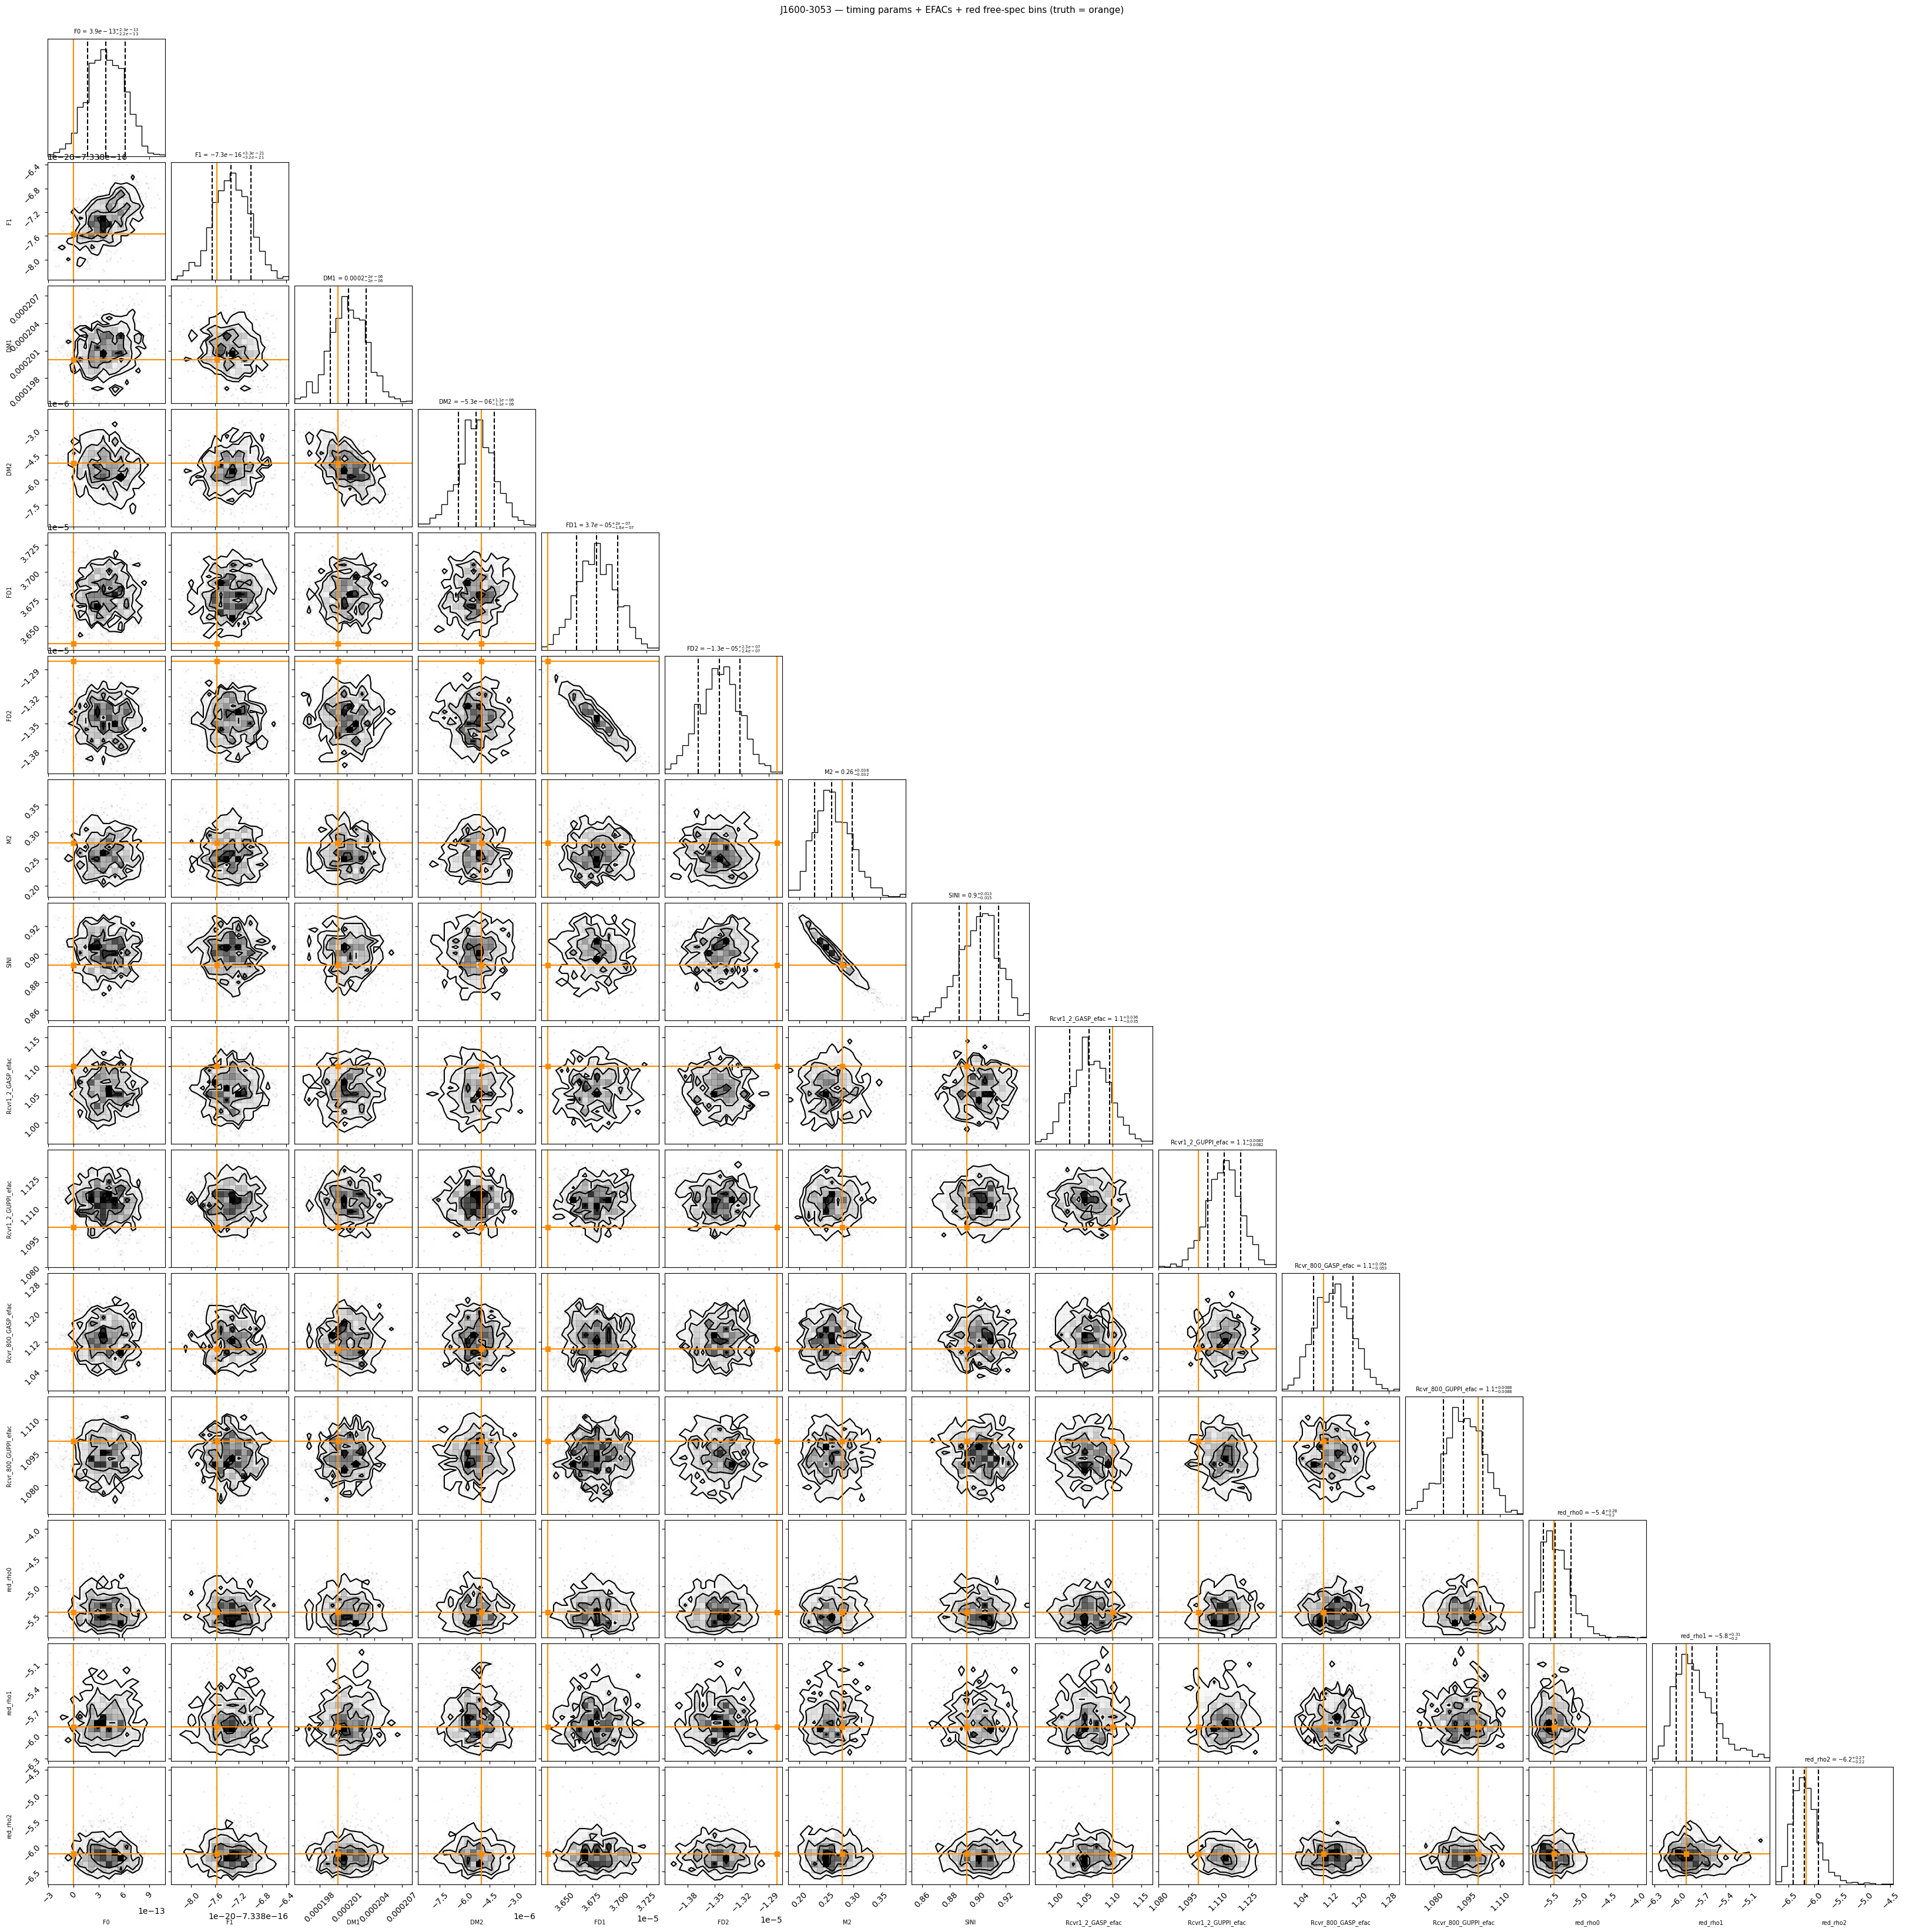

In [5]:
import corner, matplotlib.pyplot as plt
def _short(k): return k.split("gbt_")[-1] if "gbt_" in k else k

efacs = [w for w in res["white_names"] if w.endswith("efac")]
tim_show = [k for k in ["F0","F1","DM1","DM2","FD1","FD2","M2","SINI"] if k in res["samples"]]
rho = res["red_halflog10_rho"]; rho_truth = res["red_halflog10_rho_truth"]
red_idx = [0, 1, 2]                                        # 3 lowest-freq red bins

cols   = [res["samples"][k] for k in tim_show] + [res["samples"][w] for w in efacs] \
         + [rho[:, i] for i in red_idx]
labels = [_short(k) for k in tim_show] + [_short(w) for w in efacs] \
         + [f"red_rho{i}" for i in red_idx]
truths = [res["truth"][k] for k in tim_show] + [res["truth"][w] for w in efacs] \
         + [rho_truth[i] for i in red_idx]

data = np.column_stack(cols)
fig = corner.corner(data, labels=labels, truths=truths, truth_color="darkorange",
                    show_titles=True, title_fmt=".2g", quantiles=[0.16, 0.5, 0.84],
                    title_kwargs={"fontsize": 7}, label_kwargs={"fontsize": 7})
fig.suptitle("J1600-3053 — timing params + EFACs + red free-spec bins (truth = orange)",
             y=1.005, fontsize=11)
plt.show()

## 6. Inspect — recovered red free-spectrum vs injected

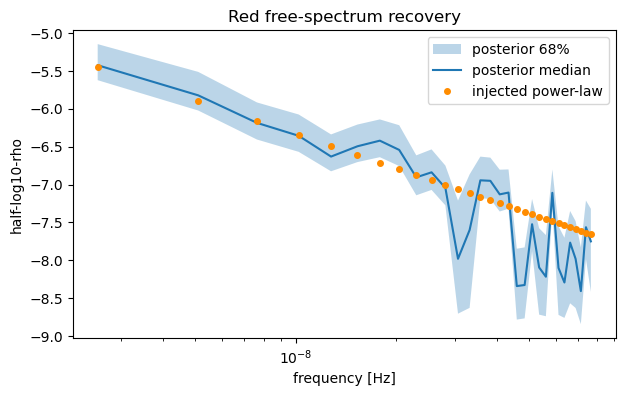

In [6]:
rho = res["red_halflog10_rho"]                     # [nsamp, NF] half-log10-rho per bin
rho_med = np.median(rho, axis=0)
lo, hi = np.percentile(rho, [16, 84], axis=0)
prob = res["problem"]; f = np.asarray(prob.sig_unc.freqs)
inj = res["red_halflog10_rho_truth"]
fig, ax = plt.subplots(figsize=(7,4))
ax.fill_between(f, lo, hi, alpha=0.3, label="posterior 68%")
ax.plot(f, rho_med, label="posterior median")
ax.plot(f, inj, "o", color="darkorange", ms=4, label="injected power-law")
ax.set_xscale("log"); ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("half-log10-rho")
ax.set_title("Red free-spectrum recovery"); ax.legend(); plt.show()

## Notes
- The timing model is sampled **nonlinearly** (JUG forward model per step) as one Gibbs
  block; ATLAS's noise (free-spec red + white) is a second block, with the red-noise
  Fourier coefficients **marginalised** — only the free-spectrum amplitudes and white
  params are sampled.  ATLAS's noise machinery is reused unchanged.
- For the timing-only control (noise held at injected truth — the widen-not-shift
  comparison), pass `sample_noise=False`.
- Single realisation. Unbiasedness is established by the seed ensemble in `VALIDATION.md`.